# Centralized model training

In [1]:
import functools
import os

from gossiplearning.config import Config
from utils.model_creators import create_MLP
from utils.multiprocessing_test import run_in_parallel

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import json
from pathlib import Path

from utils.centralized_training import train_centralized_model

In [2]:
with open("TON_IoT_config.json", "r") as f:
    config = json.load(f)

config = Config.model_validate(config)

In [3]:
timesteps = 4
dataset_path = Path("data/datasets/TON_IoT_10n_3k")
model_creator = functools.partial(create_MLP, config=config)

In [4]:
"""run_in_parallel([
    functools.partial(
        train_centralized_model,
        node_datasets_folder=dataset_path / str(i) / f"{timesteps}in",
        config=config,
        model_output_path=dataset_path / str(i) / f"{timesteps}in" / "models",
        model_creator=model_creator,
        verbose=1
    )
    for i in range(5)
])"""

'run_in_parallel([\n    functools.partial(\n        train_centralized_model,\n        node_datasets_folder=dataset_path / str(i) / f"{timesteps}in",\n        config=config,\n        model_output_path=dataset_path / str(i) / f"{timesteps}in" / "models",\n        model_creator=model_creator,\n        verbose=1\n    )\n    for i in range(5)\n])'

Epoch 0: train=0.4683, val=0.1650
Epoch 1: train=0.1488, val=0.0699
Epoch 2: train=0.0764, val=0.0279
Epoch 3: train=0.0426, val=0.0140
Epoch 4: train=0.0274, val=0.0085
Epoch 5: train=0.0196, val=0.0057
Epoch 6: train=0.0149, val=0.0042
Epoch 7: train=0.0120, val=0.0032
Epoch 8: train=0.0098, val=0.0026
Epoch 9: train=0.0083, val=0.0021
Epoch 10: train=0.0072, val=0.0018
Epoch 11: train=0.0059, val=0.0016
Epoch 12: train=0.0055, val=0.0013
Epoch 13: train=0.0049, val=0.0012
Epoch 14: train=0.0044, val=0.0010
Epoch 15: train=0.0039, val=0.0009
Epoch 16: train=0.0035, val=0.0008
Epoch 17: train=0.0035, val=0.0007
Epoch 18: train=0.0033, val=0.0007
Epoch 19: train=0.0029, val=0.0006
Epoch 20: train=0.0026, val=0.0005
Epoch 21: train=0.0027, val=0.0005
Epoch 22: train=0.0025, val=0.0005
Epoch 23: train=0.0024, val=0.0005
Epoch 24: train=0.0021, val=0.0004
Epoch 25: train=0.0021, val=0.0004
Epoch 26: train=0.0019, val=0.0004
Epoch 27: train=0.0018, val=0.0004
Epoch 28: train=0.0018, val=0.

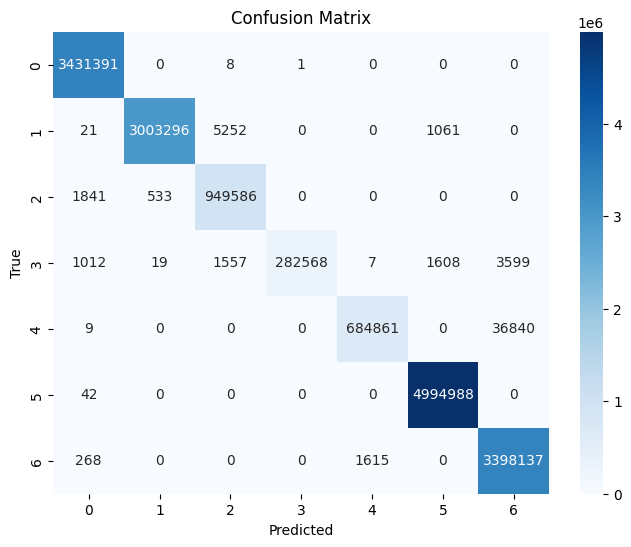

In [5]:
i = 4
train_centralized_model(
     node_datasets_folder=dataset_path / str(i) / f"4inTestBalanced",         #4inTestBalanced
     model_output_path=dataset_path / str(i) / f"4inTestBalanced" / "models",
     config=config,
     model_creator=functools.partial(create_MLP, config=config),
     verbose=1,
)

# Testing Modello Centralizzato

In [3]:
import torch
from utils.data import load_npz_data
from keras.models import load_model
simulation_number = 4

#4inTestBalanced
model = torch.load(f"data/datasets/TON_IoT_10n_3k/{simulation_number}/4inTestBalanced/models/centralized.pt")
datasets = tuple([load_npz_data(f"data/datasets/TON_IoT_10n_3k/{simulation_number}/4inTestBalanced/node_{i}.npz") for i in range(10)])

In [4]:
import numpy as np
X = np.concatenate([d[4] for d in datasets])
Y = np.concatenate([d[5] for d in datasets])

In [5]:
from pathlib import Path
import json
import torch
import torch.nn as nn
import torch.nn.functional as F

from utils.metrics import compute_metrics

class MLPModel(nn.Module):
    def __init__(self):
        super().__init__()
        input_dim = 17
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.output_layer = nn.Linear(64, 7)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        logit = self.output_layer(x)  
        return logit


loaded_model = MLPModel()
loaded_model.load_state_dict(model)

x_tensor = torch.tensor(X.astype("float32"), dtype=torch.float32)
y_tensor = torch.tensor(Y, dtype=torch.long)
history_centr = []

loaded_model.eval()
with torch.no_grad():
    logits = loaded_model(x_tensor)              
    y_pred = torch.argmax(logits, dim=1)         
    correct = (y_pred == y_tensor).sum().item()
    accuracy_centr = correct / len(y_tensor)

print("Accuracy:", accuracy_centr)
predictions_centr = y_pred.numpy()
true_centr = y_tensor.numpy()
metrics = compute_metrics(true_centr, predictions_centr)
history_centr = {
    "accuracy": metrics.acc,
    "precision_macro": metrics.prec,
    "recall_macro": metrics.rec,
    "f1_macro": metrics.f1
}
probs_centr = torch.softmax(logits, dim=1)

print("X: ", x_tensor.shape)
print("Y: ", y_tensor.shape)

path_folder = Path(f"data/datasets/TON_IoT_10n_3k/{simulation_number}/4inTestBalanced/models/")
path_folder.mkdir(parents=True, exist_ok=True)

file_path = path_folder / "report_accuracy.json"
with open(file_path, "w") as outfile:
    json.dump([history_centr], outfile, indent=1)

Accuracy: 0.9999500001041665
X:  torch.Size([2400005, 17])
Y:  torch.Size([2400005])


# Confronto con Gossip Learning

In [ ]:
import torch
import numpy as np
from utils.data import load_npz_data
simulation_number = 0

#4inTestBalanced
model = tuple([torch.load(f"experiments/TON_IoT/{simulation_number}/models/{i}.pth") for i in range(10)])
datasets = tuple([load_npz_data(f"data/datasets/TON_IoT_10n_3k/{simulation_number}/4inTestBalanced/node_{i}.npz") for i in range(10)])

X = np.concatenate([d[4] for d in datasets])
Y = np.concatenate([d[5] for d in datasets])

X:  torch.Size([2400005, 17])
Y:  torch.Size([2400005])
Initializing model from node  0
Node:  0
Accuracy: 0.7371538809294147 

Initializing model from node  1
Node:  1
Accuracy: 0.7258851544059283 

Initializing model from node  2
Node:  2
Accuracy: 0.5780208791231685 

Initializing model from node  3
Node:  3
Accuracy: 0.8433203264159866 

Initializing model from node  4
Node:  4
Accuracy: 0.7303359784667115 

Initializing model from node  5
Node:  5
Accuracy: 0.9401838746169279 

Initializing model from node  6
Node:  6
Accuracy: 0.7446209487063569 

Initializing model from node  7
Node:  7
Accuracy: 0.8741152622598702 

Initializing model from node  8
Node:  8
Accuracy: 0.7649804896239799 

Initializing model from node  9
Node:  9
Accuracy: 0.762574661302789 



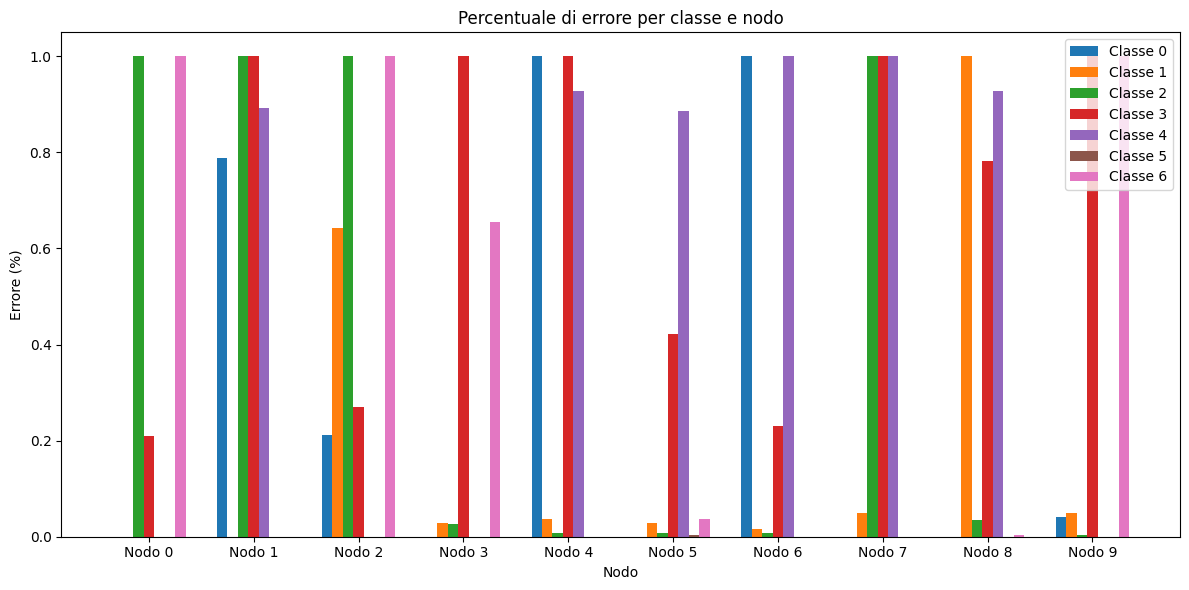

In [ ]:
from matplotlib import pyplot as plt

class MLPModel(nn.Module):
    def __init__(self):
        super().__init__()
        input_dim = 17
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.output_layer = nn.Linear(64, 7)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        logit = self.output_layer(x)  
        return logit


x_tensor = torch.tensor(X.astype("float32"), dtype=torch.float32)
y_tensor = torch.tensor(Y, dtype=torch.long)

print("X: ", x_tensor.shape)
print("Y: ", y_tensor.shape)
accuracy_gossip_list = []
history = []
num_nodes = 10
num_classes = 7

error_matrix = np.zeros((num_nodes, num_classes))

for i in range(num_nodes):
    print("Initializing model from node ", i)
    loaded_model = MLPModel()
    loaded_model.load_state_dict(model[i])

    loaded_model.eval()
    with torch.no_grad():
        logits = loaded_model(x_tensor)              
        y_pred = torch.argmax(logits, dim=1)         
        correct = (y_pred == y_tensor).sum().item()
        accuracy_gossip = correct / len(y_tensor)

    acc = ( "Node: ", str(i),
            "Accuracy:", str(accuracy_gossip))
    print("Node: ", str(i))
    print("Accuracy:", str(accuracy_gossip), "\n")
    accuracy_gossip_list.append(accuracy_gossip)
    probs = torch.softmax(logits, dim=1)

    predictions_gos = y_pred.numpy()
    true_vals = y_tensor.numpy()
    metrics = compute_metrics(true_vals, predictions_gos)
    dict_history = {
        "Node": str(i),
        "accuracy": metrics.acc,
        "precision_macro": metrics.prec,
        "recall_macro": metrics.rec,
        "f1_macro": metrics.f1
    }
    history.append(dict_history)

    path_folder = Path("experiments/TON_IoT/") / f"{simulation_number}" / "testing_unified"
    path_folder.mkdir(parents=True, exist_ok=True)

    file_path = path_folder / "report_accuracy.json"

    if not file_path.exists():
        with open(file_path, "w") as outfile:
            json.dump(dict_history, outfile, indent=1)
    else:
        with open(file_path, "r+") as outfile:
            file_data = json.load(outfile)
            if not isinstance(file_data, list):
                file_data = [file_data]
            file_data.append(dict_history)
            outfile.seek(0)
            json.dump(file_data, outfile, indent=1)
        outfile.close
    # conteggio errori per classe vera

    for c in range(num_classes):
        mask = (true_vals == c)
        errors = np.sum(predictions_gos[mask] != c)
        total = np.sum(mask)
        error_matrix[i, c] = errors / total if total > 0 else 0.0

# Plot
x = np.arange(num_nodes)  # nodi
width = 0.1               # larghezza delle barre
plt.figure(figsize=(12,6))

for c in range(num_classes):
    plt.bar(x + c*width, error_matrix[:, c], width, label=f"Classe {c}")

plt.xlabel("Nodo")
plt.ylabel("Errore (%)")
plt.title("Percentuale di errore per classe e nodo")
plt.xticks(x + (num_classes/2 - 0.5)*width, [f"Nodo {i}" for i in range(num_nodes)])
plt.legend()
plt.tight_layout()
plt.show()


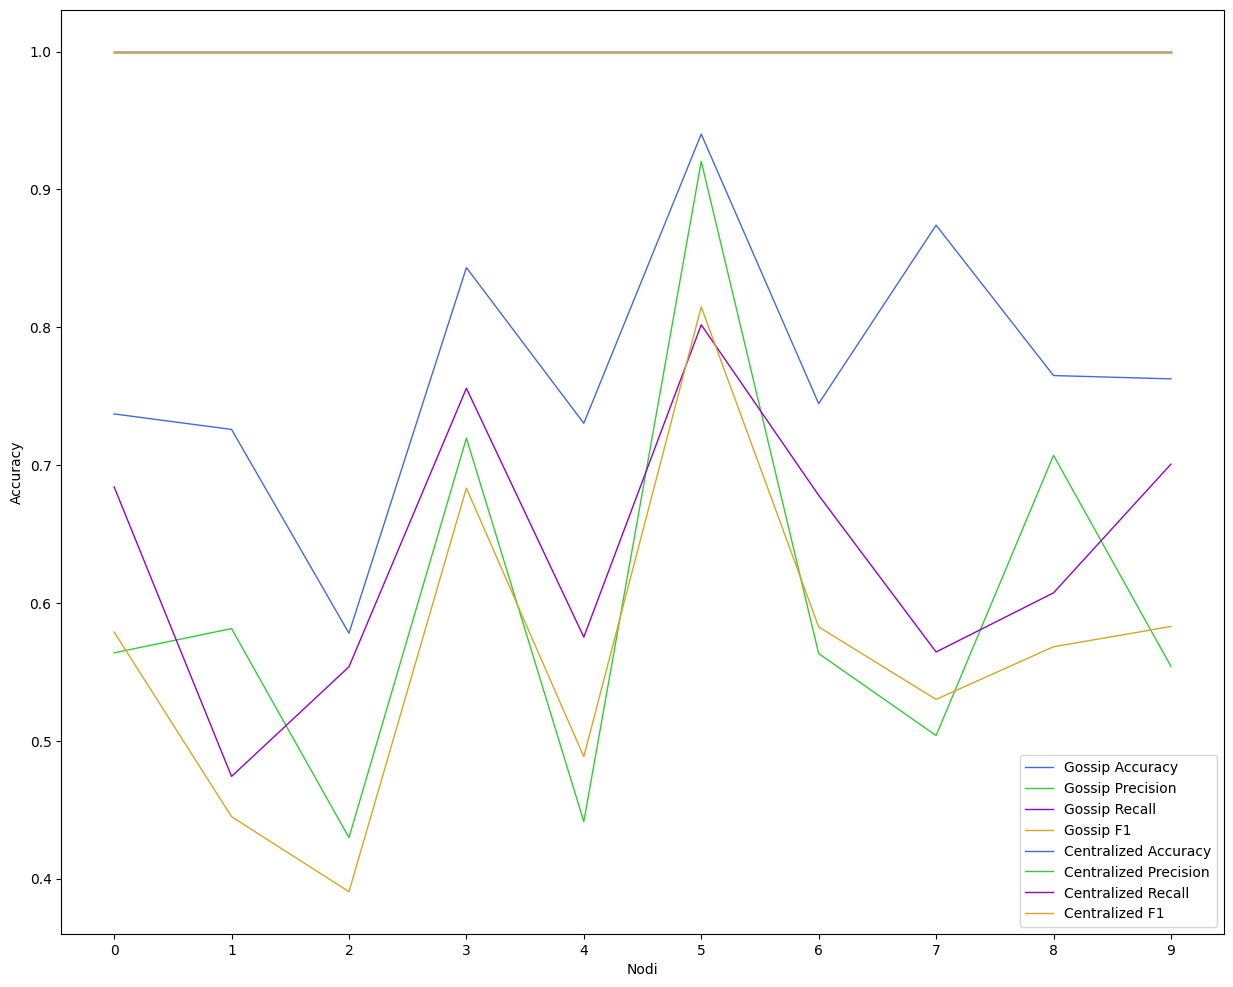

In [10]:
import matplotlib.pyplot as plt

xs = [x for x in range(len(history))]

all_acc, all_prec, all_rec, all_f1 = [], [], [], []
for i in range(len(history)):
    all_acc.append(history[i].get('accuracy'))
    all_prec.append(history[i].get('precision_macro'))
    all_rec.append(history[i].get('recall_macro'))
    all_f1.append(history[i].get('f1_macro'))

plt.figure(figsize=(15,12))
plt.xlabel("Nodi")
plt.ylabel("Accuracy")
plt.xticks(xs)
#plt.plot(xs, accuracy_gossip_list)
plt.plot(
    all_acc,
    label="Gossip Accuracy",
    color="royalblue",
    linewidth=1,
)
plt.plot(
    all_prec,
    label="Gossip Precision",
    color="limegreen",
    linewidth=1,
)
plt.plot(
    all_rec,
    label="Gossip Recall",
    color="darkviolet",
    linewidth=1,
)
plt.plot(
    all_f1,
    label="Gossip F1",
    color="goldenrod",
    linewidth=1,
)
plt.plot(
    [history_centr.get('accuracy')] * 10,
    label="Centralized Accuracy",
    color="royalblue",
    linewidth=1,
)
plt.plot(
    [history_centr.get('precision_macro')] * 10,
    label="Centralized Precision",
    color="limegreen",
    linewidth=1,
)
plt.plot(
    [history_centr.get('recall_macro')] * 10,
    label="Centralized Recall",
    color="darkviolet",
    linewidth=1,
)
plt.plot(
    [history_centr.get('f1_macro')] * 10,
    label="Centralized F1",
    color="goldenrod",
    linewidth=1,
)
plt.legend()
plt.savefig(Path(path_folder) / "comparison_plot.jpg")
plt.show()
plt.close()